In [1]:
!pip -q install timm opencv-python scikit-learn albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 369.4/369.4 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.7 MB/s eta 0:00:00


In [2]:
import os
import random
import shutil
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
from pathlib import Path
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Google Drive dataset path
ROOT_DIR = Path("/content/drive/MyDrive/aptos")

# Local working directory in Colab for faster processing
WORK_DIR = Path("/content/aptos_work")
WORK_DIR.mkdir(exist_ok=True, parents=True)

IMG_SIZE = 300
BATCH_SIZE = 16
NUM_CLASSES = 5
EPOCHS = 15
LR = 1e-4
USE_PREPROCESSING = True

Using device: cpu


In [5]:
# ===== Mount Google Drive and set dataset path =====

from google.colab import drive
from pathlib import Path
import os

# 1) Mount Google Drive
drive.mount('/content/drive')

# 2) Main dataset folder in Google Drive
# Change this path only if your aptos folder is inside another folder
ROOT_DIR = Path("/content/drive/MyDrive/aptos")

# 3) Local working directory in Colab for faster processing
WORK_DIR = Path("/content/aptos_work")
WORK_DIR.mkdir(exist_ok=True, parents=True)

# 4) Check whether dataset folder exists
print("ROOT_DIR:", ROOT_DIR)
print("ROOT_DIR exists:", ROOT_DIR.exists())

# 5) Show files/folders inside aptos
if ROOT_DIR.exists():
    print("\nContents inside aptos folder:")
    for item in ROOT_DIR.iterdir():
        print("-", item.name)
else:
    print("\nFolder not found.")
    print("Check your Drive path. Example alternatives:")
    print("/content/drive/MyDrive/datasets/aptos")
    print("/content/drive/MyDrive/project/aptos")

Mounted at /content/drive
ROOT_DIR: /content/drive/MyDrive/aptos
ROOT_DIR exists: True

Contents inside aptos folder:
- test.csv
- sample_submission.csv
- train.csv
- train_images
- test_images


In [6]:
# ===== Convert raw APTOS Kaggle dataset into organized train/val/test class folders =====

import pandas as pd
import shutil
from sklearn.model_selection import train_test_split

# Raw APTOS files
TRAIN_CSV = ROOT_DIR / "train.csv"
TRAIN_IMAGES_DIR = ROOT_DIR / "train_images"

# Output organized folder
ORG_DIR = WORK_DIR / "APTOS_organized"

label_map = {
    0: "0_No_DR",
    1: "1_Mild",
    2: "2_Moderate",
    3: "3_Severe",
    4: "4_Proliferative_DR"
}

# Create output folders
for split in ["train", "val", "test"]:
    for label_name in label_map.values():
        (ORG_DIR / split / label_name).mkdir(parents=True, exist_ok=True)

# Read CSV
df = pd.read_csv(TRAIN_CSV)
print("Total labeled images:", len(df))
print("\nClass distribution:")
print(df["diagnosis"].value_counts().sort_index())

# Stratified split: train 70%, val 15%, test 15%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["diagnosis"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["diagnosis"]
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

def copy_images(split_df, split_name):
    missing = 0
    copied = 0
    for _, row in split_df.iterrows():
        img_id = row["id_code"]
        label = row["diagnosis"]
        src = TRAIN_IMAGES_DIR / f"{img_id}.png"
        dst = ORG_DIR / split_name / label_map[label] / f"{img_id}.png"

        if src.exists():
            shutil.copy2(src, dst)
            copied += 1
        else:
            missing += 1

    print(f"{split_name}: copied={copied}, missing={missing}")

# Copy images into folders
copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

print("\nOrganized dataset created at:", ORG_DIR)

Total labeled images: 3662

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Split sizes:
Train: 2563
Val  : 549
Test : 550
train: copied=1641, missing=922
val: copied=336, missing=213
test: copied=352, missing=198

Organized dataset created at: /content/aptos_work/APTOS_organized


In [7]:
# ===== Rebuild organized dataset by detecting actual image filenames/extensions =====

import pandas as pd
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

TRAIN_CSV = ROOT_DIR / "train.csv"
TRAIN_IMAGES_DIR = ROOT_DIR / "train_images"
ORG_DIR = WORK_DIR / "APTOS_organized_fixed"

label_map = {
    0: "0_No_DR",
    1: "1_Mild",
    2: "2_Moderate",
    3: "3_Severe",
    4: "4_Proliferative_DR"
}

# Read CSV
df = pd.read_csv(TRAIN_CSV)

# Build filename lookup from actual files present
all_image_files = {}
for f in TRAIN_IMAGES_DIR.iterdir():
    if f.is_file():
        all_image_files[f.stem] = f

print("Actual image files found in train_images:", len(all_image_files))

# Keep only rows whose image really exists
df["file_path"] = df["id_code"].map(all_image_files)
missing_df = df[df["file_path"].isna()].copy()
present_df = df[df["file_path"].notna()].copy()

print("Rows with matching images:", len(present_df))
print("Rows missing images:", len(missing_df))

# Stratified split only on present images
train_df, temp_df = train_test_split(
    present_df,
    test_size=0.30,
    random_state=42,
    stratify=present_df["diagnosis"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["diagnosis"]
)

print("\nSplit sizes after filtering existing images:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# Create folders
for split in ["train", "val", "test"]:
    for label_name in label_map.values():
        (ORG_DIR / split / label_name).mkdir(parents=True, exist_ok=True)

def copy_images(split_df, split_name):
    copied = 0
    for _, row in split_df.iterrows():
        src = Path(row["file_path"])
        label = row["diagnosis"]
        dst = ORG_DIR / split_name / label_map[label] / src.name
        shutil.copy2(src, dst)
        copied += 1
    print(f"{split_name}: copied={copied}")

copy_images(train_df, "train")
copy_images(val_df, "val")
copy_images(test_df, "test")

print("\nFixed organized dataset created at:", ORG_DIR)

Actual image files found in train_images: 2329
Rows with matching images: 2329
Rows missing images: 1333

Split sizes after filtering existing images:
Train: 1630
Val  : 349
Test : 350
train: copied=1630
val: copied=349
test: copied=350

Fixed organized dataset created at: /content/aptos_work/APTOS_organized_fixed


In [8]:
# ===== Use the fixed organized dataset =====
DATA_DIR = ORG_DIR
print("DATA_DIR:", DATA_DIR)

DATA_DIR: /content/aptos_work/APTOS_organized_fixed


In [9]:
# ===== CLAHE + Gaussian blur preprocessing (paper-inspired) =====

import cv2
from pathlib import Path

PRE_DIR = WORK_DIR / "preprocessed_300"

def preprocess_fundus_image(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # CLAHE on LAB luminance channel
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img_rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Gaussian blur
    img_rgb = cv2.GaussianBlur(img_rgb, (5, 5), 0)

    return img_rgb

def preprocess_dataset(src_root, dst_root, img_size=300):
    for split in ["train", "val", "test"]:
        split_path = src_root / split
        for class_dir in split_path.iterdir():
            if not class_dir.is_dir():
                continue

            out_class = dst_root / split / class_dir.name
            out_class.mkdir(parents=True, exist_ok=True)

            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() not in [".png", ".jpg", ".jpeg"]:
                    continue

                img = cv2.imread(str(img_path))
                if img is None:
                    continue

                img = preprocess_fundus_image(img)
                img = cv2.resize(img, (img_size, img_size))

                out_path = out_class / img_path.name
                cv2.imwrite(str(out_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

if USE_PREPROCESSING:
    preprocess_dataset(DATA_DIR, PRE_DIR, img_size=IMG_SIZE)
    FINAL_DATA_DIR = PRE_DIR
    print("Using preprocessed dataset:", FINAL_DATA_DIR)
else:
    FINAL_DATA_DIR = DATA_DIR
    print("Using original dataset:", FINAL_DATA_DIR)

Using preprocessed dataset: /content/aptos_work/preprocessed_300


In [10]:
# ===== Check processed dataset counts =====

def count_images(split_dir):
    counts = {}
    total = 0
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            n = len([f for f in class_dir.iterdir() if f.is_file()])
            counts[class_dir.name] = n
            total += n
    return counts, total

for split in ["train", "val", "test"]:
    counts, total = count_images(FINAL_DATA_DIR / split)
    print(f"\n{split.upper()} total = {total}")
    print(counts)


TRAIN total = 1630
{'0_No_DR': 964, '1_Mild': 140, '2_Moderate': 357, '3_Severe': 63, '4_Proliferative_DR': 106}

VAL total = 349
{'0_No_DR': 206, '1_Mild': 30, '2_Moderate': 76, '3_Severe': 14, '4_Proliferative_DR': 23}

TEST total = 350
{'0_No_DR': 207, '1_Mild': 31, '2_Moderate': 77, '3_Severe': 13, '4_Proliferative_DR': 22}


In [11]:
# ===== Data transforms =====

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.4
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
# ===== Custom dataset wrapper =====

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np

class AlbumentationsImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = ImageFolder(root=root)
        self.transform = transform
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.samples = self.dataset.samples

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

In [14]:
# ===== Create datasets and dataloaders =====

train_ds = AlbumentationsImageFolder(FINAL_DATA_DIR / "train", transform=train_transform)
val_ds   = AlbumentationsImageFolder(FINAL_DATA_DIR / "val", transform=valid_transform)
test_ds  = AlbumentationsImageFolder(FINAL_DATA_DIR / "test", transform=valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

Classes: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
Train size: 1630
Val size: 349
Test size: 350


In [15]:
# ===== Compute class weights =====

from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

train_labels = [label for _, label in train_ds.samples]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([0.3382, 2.3286, 0.9132, 5.1746, 3.0755])


In [16]:
# ===== Model: EfficientNet-B3 + 3-layer classifier =====

import torch.nn as nn
import timm

class DRModel(nn.Module):
    def __init__(self, num_classes=5, dropout=0.4):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = DRModel(num_classes=NUM_CLASSES).to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

DRModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

In [19]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [20]:
# ===== Evaluation function =====

from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            losses.append(loss.item())

            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    loss_avg = np.mean(losses)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    return loss_avg, acc, macro_f1, qwk, np.array(all_labels), np.array(all_preds)

In [21]:
# ===== Training loop =====

best_qwk = -1
history = []

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    val_loss, val_acc, val_f1, val_qwk, _, _ = evaluate_model(model, val_loader, criterion)
    scheduler.step(val_qwk)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_qwk": val_qwk
    })

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val QWK: {val_qwk:.4f}")

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "/content/best_dr_model_b3.pth")
        print("✅ Saved best model.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/15 | Train Loss: 1.4447 | Val Loss: 0.7377 | Val Acc: 0.7765 | Val F1: 0.3222 | Val QWK: 0.7816
✅ Saved best model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 2/15 | Train Loss: 1.1576 | Val Loss: 0.6461 | Val Acc: 0.7106 | Val F1: 0.4243 | Val QWK: 0.8678
✅ Saved best model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Epoch 13/15 | Train Loss: 0.1806 | Val Loss: 0.6953 | Val Acc: 0.8395 | Val F1: 0.6208 | Val QWK: 0.8926


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 14/15 | Train Loss: 0.1487 | Val Loss: 0.7226 | Val Acc: 0.8367 | Val F1: 0.6323 | Val QWK: 0.8856


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 15/15 | Train Loss: 0.1324 | Val Loss: 0.7133 | Val Acc: 0.8367 | Val F1: 0.6242 | Val QWK: 0.8765


,epoch,train_loss,val_loss,val_acc,val_f1,val_qwk
0,1,1.444727,0.737742,0.776504,0.322243,0.781585
1,2,1.157614,0.646077,0.710602,0.424286,0.867772
2,3,0.950536,0.523312,0.770774,0.493321,0.871518
3,4,0.853423,0.532905,0.776504,0.537492,0.855812
4,5,0.761689,0.450458,0.825215,0.610878,0.883735
5,6,0.719909,0.462850,0.810888,0.594443,0.893452
6,7,0.588016,0.496573,0.816619,0.609679,0.875349
7,8,0.544187,0.449206,0.833811,0.631682,0.896276
8,9,0.428517,0.584495,0.785100,0.558386,0.869703
9,10,0.336946,0.626355,0.822350,0.627729,0.888354


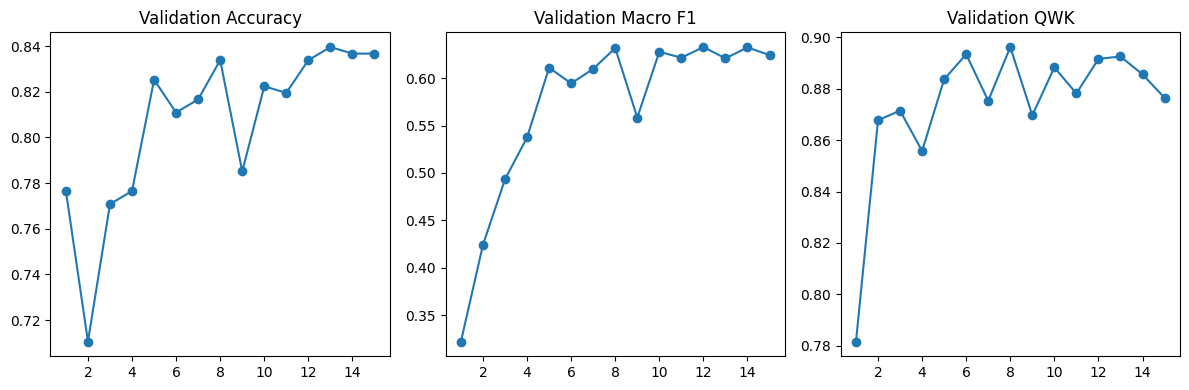

In [22]:
# ===== Plot training history =====

import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
display(hist_df)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(hist_df["epoch"], hist_df["val_acc"], marker="o")
plt.title("Validation Accuracy")

plt.subplot(1,3,2)
plt.plot(hist_df["epoch"], hist_df["val_f1"], marker="o")
plt.title("Validation Macro F1")

plt.subplot(1,3,3)
plt.plot(hist_df["epoch"], hist_df["val_qwk"], marker="o")
plt.title("Validation QWK")

plt.tight_layout()
plt.show()

In [23]:
# ===== Final test evaluation =====

model.load_state_dict(torch.load("/content/best_dr_model_b3.pth", map_location=device))

test_loss, test_acc, test_f1, test_qwk, y_true, y_pred = evaluate_model(model, test_loader, criterion)

print("===== TEST RESULTS =====")
print("Loss      :", round(test_loss, 4))
print("Accuracy  :", round(test_acc, 4))
print("Macro F1  :", round(test_f1, 4))
print("QWK       :", round(test_qwk, 4))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


===== TEST RESULTS =====
Loss      : 0.4517
Accuracy  : 0.8371
Macro F1  : 0.6646
QWK       : 0.9033


                    precision    recall  f1-score   support

           0_No_DR       0.99      0.98      0.98       207
            1_Mild       0.50      0.61      0.55        31
        2_Moderate       0.81      0.66      0.73        77
          3_Severe       0.40      0.77      0.53        13
4_Proliferative_DR       0.58      0.50      0.54        22

          accuracy                           0.84       350
         macro avg       0.65      0.70      0.66       350
      weighted avg       0.86      0.84      0.84       350

Confusion Matrix:
 [[202   5   0   0   0]
 [  2  19   8   1   1]
 [  1  13  51   8   4]
 [  0   0   0  10   3]
 [  0   1   4   6  11]]


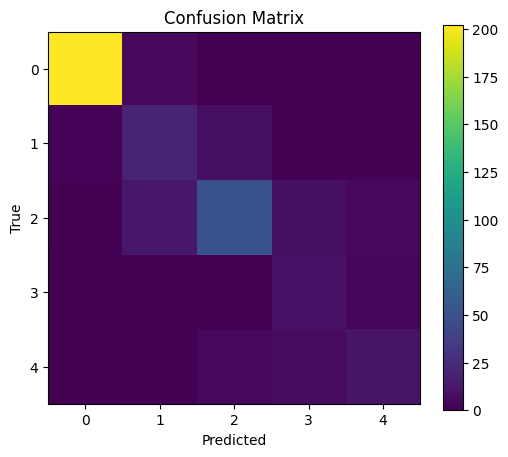

In [24]:
# ===== Detailed evaluation =====

print(classification_report(y_true, y_pred, target_names=train_ds.classes))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Class names: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


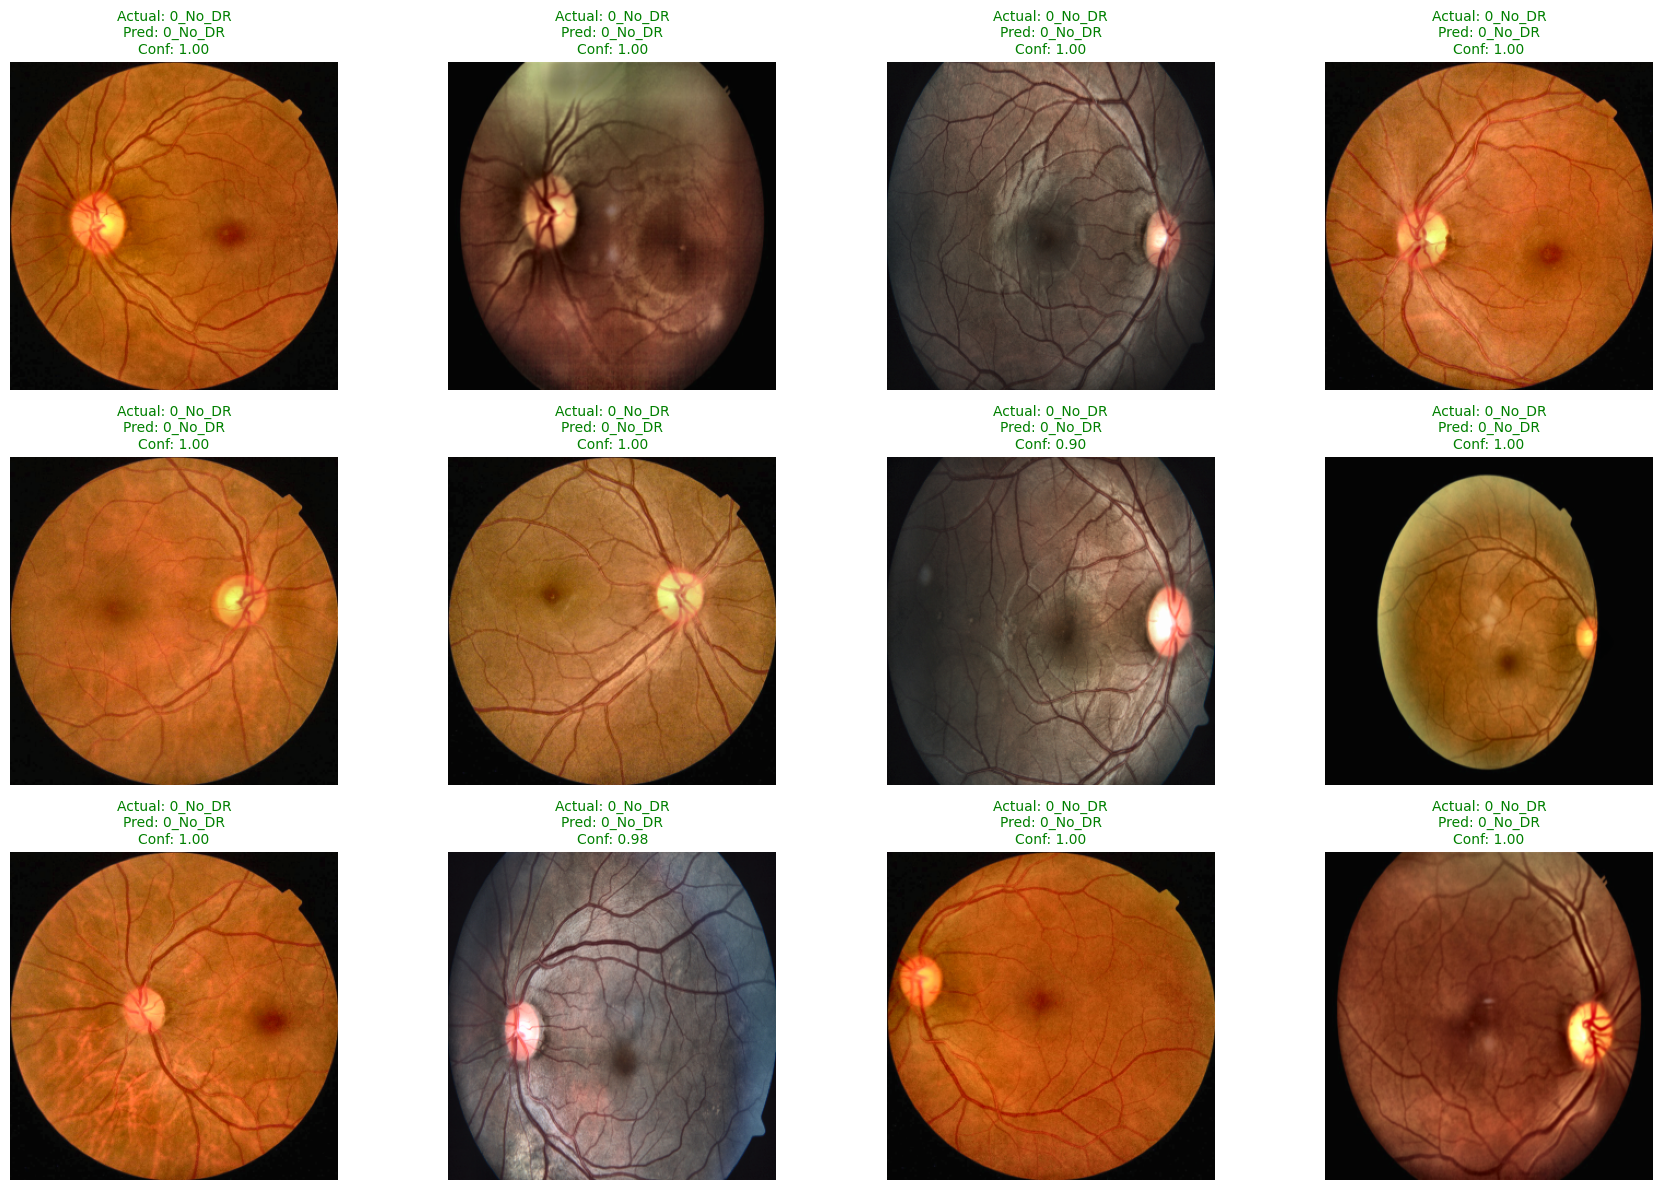

In [25]:
# ===== Show sample predictions from test set =====

import matplotlib.pyplot as plt
import numpy as np
import torch

# Load best saved model
model.load_state_dict(torch.load("/content/best_dr_model_b3.pth", map_location=device))
model.eval()

# Get class names
class_names = train_ds.classes
print("Class names:", class_names)

# Take one batch from test loader
images, labels = next(iter(test_loader))

# Move to device
images_device = images.to(device)

# Predict
with torch.no_grad():
    outputs = model(images_device)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

# Move back to CPU
images = images.cpu()
labels = labels.cpu().numpy()
preds = preds.cpu().numpy()
probs = probs.cpu().numpy()

# Unnormalize function for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def unnormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    return img

# Show first 12 predictions
num_show = min(12, len(images))
plt.figure(figsize=(18, 12))

for i in range(num_show):
    img = unnormalize(images[i])
    actual = class_names[labels[i]]
    pred = class_names[preds[i]]
    confidence = probs[i][preds[i]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    color = "green" if labels[i] == preds[i] else "red"
    plt.title(
        f"Actual: {actual}\nPred: {pred}\nConf: {confidence:.2f}",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [28]:
# ===== Create prediction table for the full test set =====

import pandas as pd
import numpy as np
import torch

model.eval()

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# Build dataframe
results_df = pd.DataFrame({
    "Actual_Label_Index": all_labels,
    "Predicted_Label_Index": all_preds
})

results_df["Actual_Label"] = results_df["Actual_Label_Index"].apply(lambda x: class_names[x])
results_df["Predicted_Label"] = results_df["Predicted_Label_Index"].apply(lambda x: class_names[x])
results_df["Correct"] = results_df["Actual_Label_Index"] == results_df["Predicted_Label_Index"]

# Confidence of predicted class
pred_conf = []
for i in range(len(all_probs)):
    pred_conf.append(float(all_probs[i][all_preds[i]]))

results_df["Pred_Confidence"] = pred_conf

print("Total test samples:", len(results_df))
display(results_df.head(100))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Total test samples: 350


,Actual_Label_Index,Predicted_Label_Index,Actual_Label,Predicted_Label,Correct,Pred_Confidence
0,0,0,0_No_DR,0_No_DR,True,0.999990
1,0,0,0_No_DR,0_No_DR,True,0.999990
2,0,0,0_No_DR,0_No_DR,True,0.999998
3,0,0,0_No_DR,0_No_DR,True,1.000000
4,0,0,0_No_DR,0_No_DR,True,0.999975
...,...,...,...,...,...,...
95,0,0,0_No_DR,0_No_DR,True,0.999632
96,0,0,0_No_DR,0_No_DR,True,1.000000
97,0,0,0_No_DR,0_No_DR,True,0.995406
98,0,1,0_No_DR,1_Mild,False,0.745194


In [29]:
# ===== Show only misclassified predictions =====

wrong_df = results_df[results_df["Correct"] == False].copy()

print("Number of wrong predictions:", len(wrong_df))
display(wrong_df.head(30))

Number of wrong predictions: 57


,Actual_Label_Index,Predicted_Label_Index,Actual_Label,Predicted_Label,Correct,Pred_Confidence
77,0,1,0_No_DR,1_Mild,False,0.642887
98,0,1,0_No_DR,1_Mild,False,0.745194
134,0,1,0_No_DR,1_Mild,False,0.960872
159,0,1,0_No_DR,1_Mild,False,0.985575
177,0,1,0_No_DR,1_Mild,False,0.464011
207,1,3,1_Mild,3_Severe,False,0.471789
208,1,2,1_Mild,2_Moderate,False,0.784605
209,1,2,1_Mild,2_Moderate,False,0.543066
213,1,2,1_Mild,2_Moderate,False,0.669332
219,1,0,1_Mild,0_No_DR,False,0.786098


In [ ]:
# ===== Use original organized dataset (no preprocessing) =====

DATA_DIR = ORG_DIR
FINAL_DATA_DIR = DATA_DIR

print("Using original dataset:", FINAL_DATA_DIR)

In [30]:
# ===== Transforms for original images (no preprocessing) =====

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.4
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [32]:
# ===== Dataset wrapper =====

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np

class AlbumentationsImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = ImageFolder(root=root)
        self.transform = transform
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.samples = self.dataset.samples

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

In [33]:
# ===== Datasets and loaders =====

train_ds = AlbumentationsImageFolder(FINAL_DATA_DIR / "train", transform=train_transform)
val_ds   = AlbumentationsImageFolder(FINAL_DATA_DIR / "val", transform=valid_transform)
test_ds  = AlbumentationsImageFolder(FINAL_DATA_DIR / "test", transform=valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

Classes: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
Train size: 1630
Val size: 349
Test size: 350


In [34]:
# ===== Class weights =====

from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

train_labels = [label for _, label in train_ds.samples]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([0.3382, 2.3286, 0.9132, 5.1746, 3.0755])


In [35]:
# ===== Model =====

import torch.nn as nn
import timm

class DRModel(nn.Module):
    def __init__(self, num_classes=5, dropout=0.4):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = DRModel(num_classes=NUM_CLASSES).to(device)
print(model)

DRModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

In [47]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [38]:
# ===== Evaluation function =====

from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            losses.append(loss.item())

            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    loss_avg = np.mean(losses)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    return loss_avg, acc, macro_f1, qwk, np.array(all_labels), np.array(all_preds)

In [43]:
# ===== Baseline training =====

best_qwk = -1
history_baseline = []

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss, val_acc, val_f1, val_qwk, _, _ = evaluate_model(model, val_loader, criterion)
    scheduler.step(val_qwk)

    history_baseline.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_qwk": val_qwk
    })

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val QWK: {val_qwk:.4f}")

    if val_qwk > best_qwk:
        best_qwk = val_qwk
        torch.save(model.state_dict(), "/content/best_dr_model_no_preprocessing.pth")
        print("Saved best baseline model.")

Epoch 1/15 | Train Loss: 0.1169 | Val Loss: 0.7049 | Val Acc: 0.8510 | Val F1: 0.6511 | Val QWK: 0.8871
Saved best baseline model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 2/15 | Train Loss: 0.0938 | Val Loss: 0.7124 | Val Acc: 0.8481 | Val F1: 0.6467 | Val QWK: 0.8871
Saved best baseline model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 3/15 | Train Loss: 0.0500 | Val Loss: 0.7340 | Val Acc: 0.8424 | Val F1: 0.6386 | Val QWK: 0.8857


...

Epoch 13/15 | Train Loss: 0.0482 | Val Loss: 0.7882 | Val Acc: 0.8338 | Val F1: 0.6177 | Val QWK: 0.8860


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 14/15 | Train Loss: 0.0530 | Val Loss: 0.7781 | Val Acc: 0.8481 | Val F1: 0.6485 | Val QWK: 0.8866


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 15/15 | Train Loss: 0.0575 | Val Loss: 0.7730 | Val Acc: 0.8510 | Val F1: 0.6477 | Val QWK: 0.8889


In [44]:
# ===== Focal Loss =====

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [45]:
# ===== Fresh model for focal loss experiment =====

model_focal = DRModel(num_classes=NUM_CLASSES).to(device)
print(model_focal)

DRModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

In [48]:
# ===== Focal loss setup =====

criterion_focal = FocalLoss(alpha=class_weights, gamma=2.0)

optimizer_focal = optim.AdamW(model_focal.parameters(), lr=LR, weight_decay=1e-4)

scheduler_focal = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_focal,
    mode="max",
    factor=0.5,
    patience=2
)

In [49]:
# ===== Train with focal loss =====

best_qwk_focal = -1
history_focal = []

for epoch in range(EPOCHS):
    model_focal.train()
    train_losses = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_focal.zero_grad()
        outputs = model_focal(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer_focal.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss, val_acc, val_f1, val_qwk, _, _ = evaluate_model(model_focal, val_loader, criterion_focal)
    scheduler_focal.step(val_qwk)

    history_focal.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_qwk": val_qwk
    })

    print(f"[Focal] Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val QWK: {val_qwk:.4f}")

    if val_qwk > best_qwk_focal:
        best_qwk_focal = val_qwk
        torch.save(model_focal.state_dict(), "/content/best_dr_model_focal.pth")
        print("Saved best focal model.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Focal] Epoch 1/15 | Train Loss: 1.1403 | Val Loss: 1.0631 | Val Acc: 0.6304 | Val F1: 0.3415 | Val QWK: 0.6019
Saved best focal model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Focal] Epoch 2/15 | Train Loss: 0.9660 | Val Loss: 0.8897 | Val Acc: 0.7364 | Val F1: 0.4778 | Val QWK: 0.7958
Saved best focal model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[Focal] Epoch 13/15 | Train Loss: 0.1631 | Val Loss: 0.9564 | Val Acc: 0.8166 | Val F1: 0.6307 | Val QWK: 0.8812


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Focal] Epoch 14/15 | Train Loss: 0.0890 | Val Loss: 1.0031 | Val Acc: 0.8252 | Val F1: 0.6190 | Val QWK: 0.8820


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Focal] Epoch 15/15 | Train Loss: 0.0842 | Val Loss: 1.0808 | Val Acc: 0.8281 | Val F1: 0.6327 | Val QWK: 0.8873


In [51]:
# ===== Focal loss test results =====

model_focal.load_state_dict(torch.load("/content/best_dr_model_focal.pth", map_location=device))

test_loss_f, test_acc_f, test_f1_f, test_qwk_f, y_true_f, y_pred_f = evaluate_model(
    model_focal, test_loader, criterion_focal
)

print("===== FOCAL LOSS TEST RESULTS =====")
print("Loss      :", round(test_loss_f, 4))
print("Accuracy  :", round(test_acc_f, 4))
print("Macro F1  :", round(test_f1_f, 4))
print("QWK       :", round(test_qwk_f, 4))

===== FOCAL LOSS TEST RESULTS =====
Loss      : 0.9009
Accuracy  : 0.7943
Macro F1  : 0.6022
QWK       : 0.9012


In [52]:
# ===== Stronger augmentation =====

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.08, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.2),
    A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2509/1905331427.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=24, max_width=24, p=0.2),


In [53]:
# ===== Test-Time Augmentation (TTA) =====

import torch

def evaluate_model_tta(model, loader, class_names):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs1 = model(images)
            probs1 = torch.softmax(outputs1, dim=1)

            flipped_images = torch.flip(images, dims=[3])  # horizontal flip
            outputs2 = model(flipped_images)
            probs2 = torch.softmax(outputs2, dim=1)

            probs = (probs1 + probs2) / 2.0
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    print("===== TTA TEST RESULTS =====")
    print("Accuracy  :", round(acc, 4))
    print("Macro F1  :", round(macro_f1, 4))
    print("QWK       :", round(qwk, 4))

    return all_labels, all_preds

In [54]:
# ===== Final experiment comparison table =====

import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Experiment": "Original + CrossEntropy",
        "Accuracy": None,
        "Macro_F1": None,
        "QWK": None
    },
    {
        "Experiment": "Original + FocalLoss",
        "Accuracy": None,
        "Macro_F1": None,
        "QWK": None
    },
    {
        "Experiment": "CLAHE+Gaussian + CrossEntropy",
        "Accuracy": 0.8371,
        "Macro_F1": 0.6646,
        "QWK": 0.9033
    }
])

comparison_df

,Experiment,Accuracy,Macro_F1,QWK
0,Original + CrossEntropy,NaN,NaN,NaN
1,Original + FocalLoss,NaN,NaN,NaN
2,CLAHE+Gaussian + CrossEntropy,0.8371,0.6646,0.9033


In [55]:
# ===== Print metrics line by line safely =====

print("test_loss =", test_loss)
print("test_acc  =", test_acc)
print("test_f1   =", test_f1)
print("test_qwk  =", test_qwk)

print("\nRounded values:")
print("Loss      :", round(float(test_loss), 4) if not np.isnan(test_loss) else "NaN")
print("Accuracy  :", round(float(test_acc), 4) if not np.isnan(test_acc) else "NaN")
print("Macro F1  :", round(float(test_f1), 4) if not np.isnan(test_f1) else "NaN")
print("QWK       :", round(float(test_qwk), 4) if not np.isnan(test_qwk) else "NaN")

test_loss = 0.45168441480067983
test_acc  = 0.8371428571428572
test_f1   = 0.664555949170355
test_qwk  = 0.9033226957011451

Rounded values:
Loss      : 0.4517
Accuracy  : 0.8371
Macro F1  : 0.6646
QWK       : 0.9033


In [56]:
# ===== Print focal experiment metrics safely =====

print("test_loss_f =", test_loss_f)
print("test_acc_f  =", test_acc_f)
print("test_f1_f   =", test_f1_f)
print("test_qwk_f  =", test_qwk_f)

print("\nRounded focal values:")
print("Loss      :", round(float(test_loss_f), 4) if not np.isnan(test_loss_f) else "NaN")
print("Accuracy  :", round(float(test_acc_f), 4) if not np.isnan(test_acc_f) else "NaN")
print("Macro F1  :", round(float(test_f1_f), 4) if not np.isnan(test_f1_f) else "NaN")
print("QWK       :", round(float(test_qwk_f), 4) if not np.isnan(test_qwk_f) else "NaN")

test_loss_f = 0.9008666889874969
test_acc_f  = 0.7942857142857143
test_f1_f   = 0.6022160135764258
test_qwk_f  = 0.9012250188142822

Rounded focal values:
Loss      : 0.9009
Accuracy  : 0.7943
Macro F1  : 0.6022
QWK       : 0.9012


In [57]:
# ===== Original images baseline =====

DATA_DIR = ORG_DIR
FINAL_DATA_DIR = DATA_DIR

print("Using original dataset:", FINAL_DATA_DIR)

Using original dataset: /content/aptos_work/APTOS_organized_fixed


In [58]:
# ===== Transforms =====

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.4
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [59]:
# ===== Dataset wrapper =====

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np

class AlbumentationsImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = ImageFolder(root=root)
        self.transform = transform
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.samples = self.dataset.samples

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

In [60]:
# ===== Datasets and dataloaders =====

train_ds = AlbumentationsImageFolder(FINAL_DATA_DIR / "train", transform=train_transform)
val_ds   = AlbumentationsImageFolder(FINAL_DATA_DIR / "val", transform=valid_transform)
test_ds  = AlbumentationsImageFolder(FINAL_DATA_DIR / "test", transform=valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

Classes: ['0_No_DR', '1_Mild', '2_Moderate', '3_Severe', '4_Proliferative_DR']
Train size: 1630
Val size: 349
Test size: 350


In [61]:
# ===== Class weights =====

from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

train_labels = [label for _, label in train_ds.samples]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([0.3382, 2.3286, 0.9132, 5.1746, 3.0755])


In [62]:
# ===== Model =====

import torch.nn as nn
import timm

class DRModel(nn.Module):
    def __init__(self, num_classes=5, dropout=0.4):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0,
            global_pool="avg"
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model_ce = DRModel(num_classes=NUM_CLASSES).to(device)
print(model_ce)

DRModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
          (bn1): BatchNormAct2d(
            40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

In [64]:
# ===== Weighted CrossEntropy setup =====

import torch.optim as optim

criterion_ce = nn.CrossEntropyLoss(weight=class_weights)

optimizer_ce = optim.AdamW(model_ce.parameters(), lr=LR, weight_decay=1e-4)

scheduler_ce = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ce,
    mode="max",
    factor=0.5,
    patience=2
)

In [65]:
# ===== Evaluation function =====

from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            losses.append(loss.item())

            preds = torch.argmax(outputs, dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    loss_avg = np.mean(losses)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    return loss_avg, acc, macro_f1, qwk, np.array(all_labels), np.array(all_preds)

In [66]:
# ===== Train Original + Weighted CrossEntropy =====

best_qwk_ce = -1
history_ce = []

for epoch in range(EPOCHS):
    model_ce.train()
    train_losses = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_ce.zero_grad()
        outputs = model_ce(images)
        loss = criterion_ce(outputs, labels)
        loss.backward()
        optimizer_ce.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss, val_acc, val_f1, val_qwk, _, _ = evaluate_model(model_ce, val_loader, criterion_ce)
    scheduler_ce.step(val_qwk)

    history_ce.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "val_qwk": val_qwk
    })

    print(f"[Original + CE] Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val QWK: {val_qwk:.4f}")

    if val_qwk > best_qwk_ce:
        best_qwk_ce = val_qwk
        torch.save(model_ce.state_dict(), "/content/best_dr_model_original_ce.pth")
        print("Saved best original+CE model.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Original + CE] Epoch 1/15 | Train Loss: 1.4661 | Val Loss: 0.8775 | Val Acc: 0.7708 | Val F1: 0.3690 | Val QWK: 0.7451
Saved best original+CE model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Original + CE] Epoch 2/15 | Train Loss: 1.1405 | Val Loss: 0.5666 | Val Acc: 0.7593 | Val F1: 0.5117 | Val QWK: 0.8571
Saved best original+CE model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[Original + CE] Epoch 13/15 | Train Loss: 0.2026 | Val Loss: 0.6818 | Val Acc: 0.8481 | Val F1: 0.6565 | Val QWK: 0.8883


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Original + CE] Epoch 14/15 | Train Loss: 0.1619 | Val Loss: 0.6605 | Val Acc: 0.8453 | Val F1: 0.6548 | Val QWK: 0.9042
Saved best original+CE model.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[Original + CE] Epoch 15/15 | Train Loss: 0.1517 | Val Loss: 0.7246 | Val Acc: 0.8539 | Val F1: 0.6563 | Val QWK: 0.8991


In [67]:
# ===== Test Original + Weighted CrossEntropy =====

model_ce.load_state_dict(torch.load("/content/best_dr_model_original_ce.pth", map_location=device))

test_loss_ce, test_acc_ce, test_f1_ce, test_qwk_ce, y_true_ce, y_pred_ce = evaluate_model(
    model_ce, test_loader, criterion_ce
)

print("===== ORIGINAL + WEIGHTED CE TEST RESULTS =====")
print("Loss      :", round(float(test_loss_ce), 4))
print("Accuracy  :", round(float(test_acc_ce), 4))
print("Macro F1  :", round(float(test_f1_ce), 4))
print("QWK       :", round(float(test_qwk_ce), 4))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


===== ORIGINAL + WEIGHTED CE TEST RESULTS =====
Loss      : 0.5849
Accuracy  : 0.8486
Macro F1  : 0.6723
QWK       : 0.9157


In [68]:
# ===== Detailed evaluation =====

print(classification_report(y_true_ce, y_pred_ce, target_names=train_ds.classes))

cm_ce = confusion_matrix(y_true_ce, y_pred_ce)
print("Confusion Matrix:\n", cm_ce)

                    precision    recall  f1-score   support

           0_No_DR       0.98      0.99      0.98       207
            1_Mild       0.55      0.55      0.55        31
        2_Moderate       0.75      0.71      0.73        77
          3_Severe       0.43      0.46      0.44        13
4_Proliferative_DR       0.62      0.68      0.65        22

          accuracy                           0.85       350
         macro avg       0.67      0.68      0.67       350
      weighted avg       0.85      0.85      0.85       350

Confusion Matrix:
 [[204   3   0   0   0]
 [  3  17  11   0   0]
 [  1  10  55   5   6]
 [  0   0   4   6   3]
 [  0   1   3   3  15]]


In [69]:
# ===== Comparison summary =====

print("Original + Weighted CE")
print("  Accuracy :", test_acc_ce)
print("  Macro F1 :", test_f1_ce)
print("  QWK      :", test_qwk_ce)

print("\nOriginal + Focal Loss")
print("  Accuracy :", 0.7943)
print("  Macro F1 :", 0.6022)
print("  QWK      :", 0.9012)

print("\nCLAHE + Gaussian + Weighted CE")
print("  Accuracy :", 0.8371)
print("  Macro F1 :", 0.6646)
print("  QWK      :", 0.9033)

Original + Weighted CE
  Accuracy : 0.8485714285714285
  Macro F1 : 0.6722942635431863
  QWK      : 0.9156939040207522

Original + Focal Loss
  Accuracy : 0.7943
  Macro F1 : 0.6022
  QWK      : 0.9012

CLAHE + Gaussian + Weighted CE
  Accuracy : 0.8371
  Macro F1 : 0.6646
  QWK      : 0.9033


In [70]:
# ===== TTA evaluation for best model =====

import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

def evaluate_model_tta(model, loader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # original prediction
            outputs1 = model(images)
            probs1 = torch.softmax(outputs1, dim=1)

            # horizontal flip prediction
            flipped_images = torch.flip(images, dims=[3])
            outputs2 = model(flipped_images)
            probs2 = torch.softmax(outputs2, dim=1)

            # average probabilities
            probs = (probs1 + probs2) / 2.0
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    print("===== TTA TEST RESULTS =====")
    print("Accuracy  :", round(float(acc), 4))
    print("Macro F1  :", round(float(macro_f1), 4))
    print("QWK       :", round(float(qwk), 4))

    return np.array(all_labels), np.array(all_preds), acc, macro_f1, qwk

In [71]:
# ===== Load best Original + Weighted CE model and run TTA =====

model_ce.load_state_dict(torch.load("/content/best_dr_model_original_ce.pth", map_location=device))

y_true_tta, y_pred_tta, acc_tta, f1_tta, qwk_tta = evaluate_model_tta(model_ce, test_loader)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


===== TTA TEST RESULTS =====
Accuracy  : 0.8457
Macro F1  : 0.6574
QWK       : 0.9153


In [72]:
# ===== Compare normal vs TTA =====

print("Original + Weighted CE (normal)")
print("  Accuracy :", 0.8486)
print("  Macro F1 :", 0.6723)
print("  QWK      :", 0.9157)

print("\nOriginal + Weighted CE + TTA")
print("  Accuracy :", round(float(acc_tta), 4))
print("  Macro F1 :", round(float(f1_tta), 4))
print("  QWK      :", round(float(qwk_tta), 4))

Original + Weighted CE (normal)
  Accuracy : 0.8486
  Macro F1 : 0.6723
  QWK      : 0.9157

Original + Weighted CE + TTA
  Accuracy : 0.8457
  Macro F1 : 0.6574
  QWK      : 0.9153


In [73]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true_tta, y_pred_tta, target_names=train_ds.classes))

cm_tta = confusion_matrix(y_true_tta, y_pred_tta)
print("Confusion Matrix:\n", cm_tta)

                    precision    recall  f1-score   support

           0_No_DR       0.98      0.99      0.99       207
            1_Mild       0.56      0.58      0.57        31
        2_Moderate       0.76      0.69      0.72        77
          3_Severe       0.36      0.38      0.37        13
4_Proliferative_DR       0.60      0.68      0.64        22

          accuracy                           0.85       350
         macro avg       0.65      0.67      0.66       350
      weighted avg       0.85      0.85      0.85       350

Confusion Matrix:
 [[205   2   0   0   0]
 [  3  18  10   0   0]
 [  1  11  53   6   6]
 [  0   0   4   5   4]
 [  0   1   3   3  15]]
